# BC5CDR — Full EDA + NER + Relation Extraction Pipeline
### PubMedBERT · Chemical/Disease NER · CID Relation Extraction
---
Run cells top to bottom. GPU runtime required for training cells.

In [2]:
!pip install transformers seqeval scikit-learn nltk matplotlib seaborn -q
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


True

## PHASE 1 — Dataset Loading & Validation

In [3]:
from google.colab import files
print('Upload CDR_TrainingSet.PubTator, CDR_DevelopmentSet.PubTator, CDR_TestSet.PubTator')
uploaded = files.upload()
print('Uploaded:', list(uploaded.keys()))

Upload CDR_TrainingSet.PubTator, CDR_DevelopmentSet.PubTator, CDR_TestSet.PubTator


Saving CDR_TrainingSet.PubTator.txt to CDR_TrainingSet.PubTator.txt
Saving CDR_DevelopmentSet.PubTator.txt to CDR_DevelopmentSet.PubTator.txt
Saving CDR_TestSet.PubTator.txt to CDR_TestSet.PubTator.txt
Uploaded: ['CDR_TrainingSet.PubTator.txt', 'CDR_DevelopmentSet.PubTator.txt', 'CDR_TestSet.PubTator.txt']


In [4]:
def parse_pubtator(filepath):
    documents, errors = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()
    blocks = [b.strip() for b in content.strip().split('\n\n') if b.strip()]
    for block in blocks:
        lines = block.split('\n')
        doc = {'pmid': None, 'title': '', 'abstract': '', 'entities': [], 'relations': []}
        for line in lines:
            if '|t|' in line:
                parts = line.split('|t|', 1)
                doc['pmid'] = parts[0].strip()
                doc['title'] = parts[1].strip()
            elif '|a|' in line:
                doc['abstract'] = line.split('|a|', 1)[1].strip()
            elif '\t' in line:
                parts = line.split('\t')
                if len(parts) >= 5 and parts[1].isdigit() and parts[2].isdigit():
                    doc['entities'].append({
                        'start': int(parts[1]), 'end': int(parts[2]),
                        'text': parts[3], 'type': parts[4].strip(),
                        'mesh_id': parts[5].strip() if len(parts) > 5 else ''
                    })
                elif len(parts) == 4 and parts[1].strip() == 'CID':
                    doc['relations'].append({'type': 'CID', 'chem_id': parts[2].strip(), 'disease_id': parts[3].strip()})
        if doc['pmid'] is None:
            errors.append({'block': block[:80], 'reason': 'Missing PMID'})
            continue
        if not doc['title'] and not doc['abstract']:
            errors.append({'pmid': doc['pmid'], 'reason': 'No text'})
        doc['full_text'] = doc['title'] + ' ' + doc['abstract']
        documents.append(doc)
    return documents, errors

In [5]:
train_docs, train_err = parse_pubtator('CDR_TrainingSet.PubTator.txt')
dev_docs,   dev_err   = parse_pubtator('CDR_DevelopmentSet.PubTator.txt')
test_docs,  test_err  = parse_pubtator('CDR_TestSet.PubTator.txt')

print(f'Parsed  — Train: {len(train_docs)} | Dev: {len(dev_docs)} | Test: {len(test_docs)}')
print(f'Errors  — Train: {len(train_err)}  | Dev: {len(dev_err)}  | Test: {len(test_err)}')
if train_err:
    print('Sample errors:', train_err[:3])

Parsed  — Train: 500 | Dev: 500 | Test: 500
Errors  — Train: 0  | Dev: 0  | Test: 0


In [6]:
offset_mismatches = []
for split_name, docs in [('train', train_docs), ('dev', dev_docs), ('test', test_docs)]:
    for doc in docs:
        text = doc['full_text']
        for ent in doc['entities']:
            s, e = ent['start'], ent['end']
            actual = text[s:e]
            if actual.lower() != ent['text'].lower():
                offset_mismatches.append({'split': split_name, 'pmid': doc['pmid'],
                    'expected': ent['text'], 'actual': actual, 'start': s, 'end': e})

print(f'Offset mismatches: {len(offset_mismatches)}')
for m in offset_mismatches[:5]:
    print(f"  PMID {m['pmid']}: expected={m['expected']!r} actual={m['actual']!r}")

Offset mismatches: 0


In [7]:
relation_issues = []
for split_name, docs in [('train', train_docs), ('dev', dev_docs), ('test', test_docs)]:
    for doc in docs:
        chem_ids = {e['mesh_id'] for e in doc['entities'] if e['type'] == 'Chemical'}
        dis_ids  = {e['mesh_id'] for e in doc['entities'] if e['type'] == 'Disease'}
        for rel in doc['relations']:
            if rel['chem_id'] not in chem_ids or rel['disease_id'] not in dis_ids:
                relation_issues.append({'split': split_name, 'pmid': doc['pmid'],
                    'chem_ok': rel['chem_id'] in chem_ids, 'dis_ok': rel['disease_id'] in dis_ids})

print(f'CID pairs with unresolved MeSH IDs: {len(relation_issues)}')
print('Phase 1 complete.')

CID pairs with unresolved MeSH IDs: 127
Phase 1 complete.


## PHASE 2 — Structural Dataset Analysis


--- TRAIN (500 docs) ---
  Chemical entities     : 5203
  Disease  entities     : 4182
  Chem:Dis ratio        : 1.24
  Entities/doc avg/max  : 18.8 / 60
  Entities/doc p90      : 30

--- DEV (500 docs) ---
  Chemical entities     : 5347
  Disease  entities     : 4244
  Chem:Dis ratio        : 1.26
  Entities/doc avg/max  : 19.2 / 59
  Entities/doc p90      : 31

--- TEST (500 docs) ---
  Chemical entities     : 5385
  Disease  entities     : 4424
  Chem:Dis ratio        : 1.22
  Entities/doc avg/max  : 19.6 / 69
  Entities/doc p90      : 32


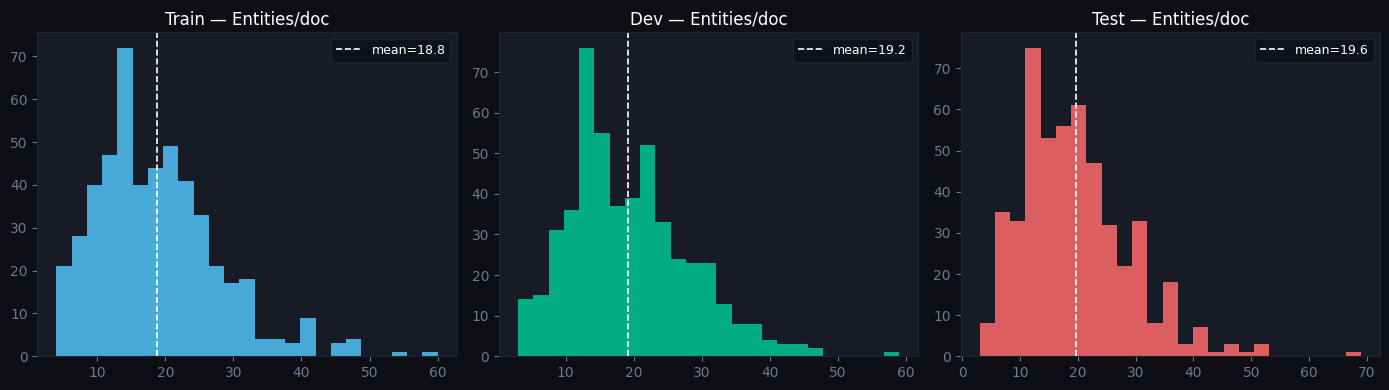

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def split_stats(docs, name):
    n_chem, n_dis, epd = 0, 0, []
    for doc in docs:
        c = sum(1 for e in doc['entities'] if e['type'] == 'Chemical')
        d = sum(1 for e in doc['entities'] if e['type'] == 'Disease')
        n_chem += c; n_dis += d; epd.append(c + d)
    arr = np.array(epd)
    print(f'\n--- {name} ({len(docs)} docs) ---')
    print(f'  Chemical entities     : {n_chem}')
    print(f'  Disease  entities     : {n_dis}')
    print(f'  Chem:Dis ratio        : {n_chem/max(n_dis,1):.2f}')
    print(f'  Entities/doc avg/max  : {arr.mean():.1f} / {arr.max()}')
    print(f'  Entities/doc p90      : {np.percentile(arr,90):.0f}')
    return arr

tr_epd = split_stats(train_docs, 'TRAIN')
dv_epd = split_stats(dev_docs,   'DEV')
ts_epd = split_stats(test_docs,  'TEST')

fig, axes = plt.subplots(1, 3, figsize=(14, 4), facecolor='#0d0f14')
for ax, arr, name, color in zip(axes,
        [tr_epd, dv_epd, ts_epd], ['Train','Dev','Test'], ['#4fc3f7','#00c896','#ff6b6b']):
    ax.set_facecolor('#161b25')
    ax.hist(arr, bins=25, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(arr.mean(), color='white', linestyle='--', lw=1.2, label=f'mean={arr.mean():.1f}')
    ax.set_title(f'{name} — Entities/doc', color='white')
    ax.tick_params(colors='#6b7a8d'); ax.spines[:].set_color('#1e2635')
    ax.legend(fontsize=9, labelcolor='white', facecolor='#0d0f14', edgecolor='#1e2635')
plt.tight_layout(); plt.show()

## PHASE 3 — Relation Distribution Analysis


--- TRAIN ---
  Positive CID pairs     : 1038
  Total candidate pairs  : 42384
  Negative (no_relation) : 41346
  Pos:Neg ratio          : 1:39.8
  Pairs/doc avg / max    : 84.8 / 864
  High-pair docs (>50)   : 285
    PMID 10669626: 36x24=864 pairs, 1 pos
    PMID 12464714: 40x15=600 pairs, 2 pos
    PMID 10704919: 31x15=465 pairs, 2 pos

--- DEV ---
  Positive CID pairs     : 1012
  Total candidate pairs  : 45779
  Negative (no_relation) : 44767
  Pos:Neg ratio          : 1:44.2
  Pairs/doc avg / max    : 91.6 / 828
  High-pair docs (>50)   : 286
    PMID 17042884: 36x23=828 pairs, 5 pos
    PMID 12093990: 18x28=504 pairs, 2 pos
    PMID 11999899: 24x21=504 pairs, 3 pos

--- TEST ---
  Positive CID pairs     : 1066
  Total candidate pairs  : 47363
  Negative (no_relation) : 46297
  Pos:Neg ratio          : 1:43.4
  Pairs/doc avg / max    : 94.7 / 770
  High-pair docs (>50)   : 311
    PMID 15630069: 55x14=770 pairs, 2 pos
    PMID 8996419: 33x19=627 pairs, 1 pos
    PMID 17297207: 1

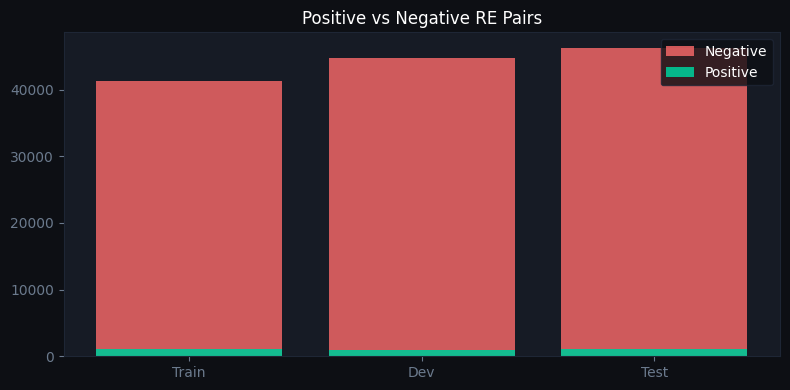

In [9]:
def relation_analysis(docs, name):
    total_pos, total_pairs, pair_counts, explosive = 0, 0, [], []
    for doc in docs:
        nc = sum(1 for e in doc['entities'] if e['type']=='Chemical')
        nd = sum(1 for e in doc['entities'] if e['type']=='Disease')
        pairs = nc * nd
        pos   = len(doc['relations'])
        total_pos += pos; total_pairs += pairs; pair_counts.append(pairs)
        if pairs > 50:
            explosive.append({'pmid': doc['pmid'], 'nc': nc, 'nd': nd, 'pairs': pairs, 'pos': pos})
    neg = total_pairs - total_pos
    print(f'\n--- {name} ---')
    print(f'  Positive CID pairs     : {total_pos}')
    print(f'  Total candidate pairs  : {total_pairs}')
    print(f'  Negative (no_relation) : {neg}')
    print(f'  Pos:Neg ratio          : 1:{neg/max(total_pos,1):.1f}')
    print(f'  Pairs/doc avg / max    : {np.mean(pair_counts):.1f} / {max(pair_counts)}')
    print(f'  High-pair docs (>50)   : {len(explosive)}')
    for d in sorted(explosive, key=lambda x: -x['pairs'])[:3]:
        print(f"    PMID {d['pmid']}: {d['nc']}x{d['nd']}={d['pairs']} pairs, {d['pos']} pos")
    return total_pos, neg

tr_p, tr_n = relation_analysis(train_docs, 'TRAIN')
dv_p, dv_n = relation_analysis(dev_docs,   'DEV')
ts_p, ts_n = relation_analysis(test_docs,  'TEST')

fig, ax = plt.subplots(figsize=(8, 4), facecolor='#0d0f14')
ax.set_facecolor('#161b25')
x = np.arange(3)
ax.bar(x, [tr_n, dv_n, ts_n], label='Negative', color='#ff6b6b', alpha=0.8)
ax.bar(x, [tr_p, dv_p, ts_p], label='Positive', color='#00c896', alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(['Train','Dev','Test'], color='white')
ax.tick_params(colors='#6b7a8d'); ax.spines[:].set_color('#1e2635')
ax.set_title('Positive vs Negative RE Pairs', color='white')
ax.legend(facecolor='#0d0f14', edgecolor='#1e2635', labelcolor='white')
plt.tight_layout(); plt.show()

## PHASE 4 — Text & Sequence Length Analysis

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]


--- TRAIN ---
  Char  avg/max/p90  : 1305 / 3538 / 1999
  Token avg/max/p90  : 257 / 672 / 417
  Truncated at 256   : 238 (47.6%)
  Truncated at 512   : 18 (3.6%)

--- DEV ---
  Char  avg/max/p90  : 1294 / 3907 / 1980
  Token avg/max/p90  : 256 / 685 / 409
  Truncated at 256   : 234 (46.8%)
  Truncated at 512   : 15 (3.0%)

--- TEST ---
  Char  avg/max/p90  : 1355 / 3310 / 1988
  Token avg/max/p90  : 271 / 722 / 422
  Truncated at 256   : 268 (53.6%)
  Truncated at 512   : 13 (2.6%)


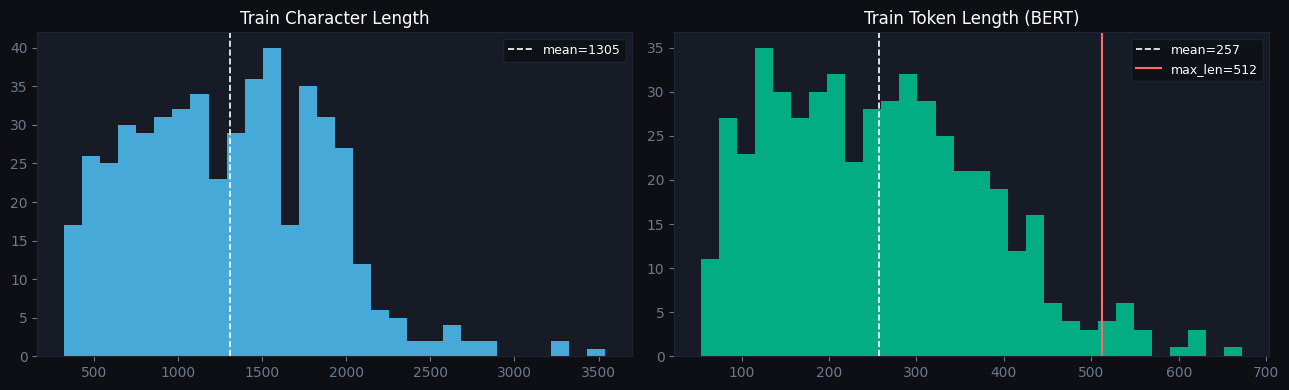

In [10]:
from transformers import AutoTokenizer
MODEL_NAME = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def seq_analysis(docs, name):
    cl, tl = [], []
    for doc in docs:
        t = doc['full_text']
        cl.append(len(t))
        tl.append(len(tokenizer.encode(t, truncation=False)))
    cl, tl = np.array(cl), np.array(tl)
    print(f'\n--- {name} ---')
    print(f'  Char  avg/max/p90  : {cl.mean():.0f} / {cl.max()} / {np.percentile(cl,90):.0f}')
    print(f'  Token avg/max/p90  : {tl.mean():.0f} / {tl.max()} / {np.percentile(tl,90):.0f}')
    print(f'  Truncated at 256   : {(tl>256).sum()} ({100*(tl>256).mean():.1f}%)')
    print(f'  Truncated at 512   : {(tl>512).sum()} ({100*(tl>512).mean():.1f}%)')
    return cl, tl

tr_cl, tr_tl = seq_analysis(train_docs, 'TRAIN')
dv_cl, dv_tl = seq_analysis(dev_docs,   'DEV')
ts_cl, ts_tl = seq_analysis(test_docs,  'TEST')

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor='#0d0f14')
for ax, data, title, thresh, color in [
    (axes[0], tr_cl, 'Train Character Length',   None, '#4fc3f7'),
    (axes[1], tr_tl, 'Train Token Length (BERT)', 512, '#00c896')]:
    ax.set_facecolor('#161b25')
    ax.hist(data, bins=30, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(data.mean(), color='white', linestyle='--', lw=1.2, label=f'mean={data.mean():.0f}')
    if thresh:
        ax.axvline(thresh, color='#ff6b6b', linestyle='-', lw=1.5, label=f'max_len={thresh}')
    ax.set_title(title, color='white')
    ax.tick_params(colors='#6b7a8d'); ax.spines[:].set_color('#1e2635')
    ax.legend(facecolor='#0d0f14', edgecolor='#1e2635', labelcolor='white', fontsize=9)
plt.tight_layout(); plt.show()

## PHASE 5 — Sentence-Level Optimization


--- TRAIN ---
  Total resolved CID    : 986
  Same-sentence CID     : 265  (26.9%)
  Cross-sentence CID    : 721 (73.1%)

--- DEV ---
  Total resolved CID    : 961
  Same-sentence CID     : 291  (30.3%)
  Cross-sentence CID    : 670 (69.7%)

--- TEST ---
  Total resolved CID    : 1042
  Same-sentence CID     : 292  (28.0%)
  Cross-sentence CID    : 750 (72.0%)


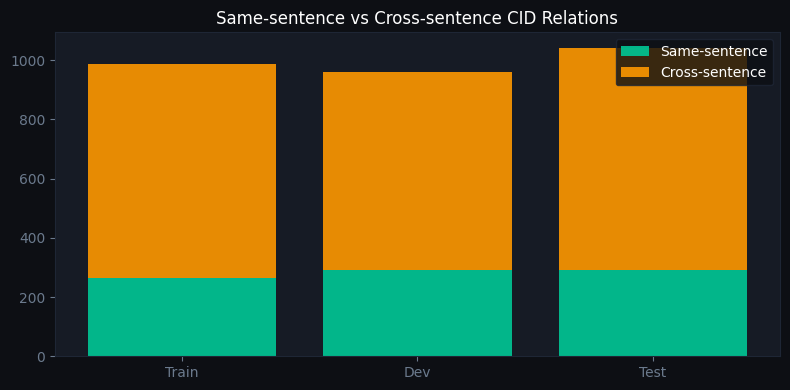


71.6% of CIDs are cross-sentence.
Decision: use ABSTRACT-LEVEL input to capture cross-sentence relations.


In [11]:
from nltk.tokenize import sent_tokenize

def cross_sentence_analysis(docs, name):
    same, cross, total = 0, 0, 0
    for doc in docs:
        text  = doc['full_text']
        sents = sent_tokenize(text)
        spans = []
        cursor = 0
        for s in sents:
            idx = text.find(s, cursor)
            if idx != -1:
                spans.append((idx, idx + len(s)))
                cursor = idx + len(s)

        def sent_idx(pos):
            for i, (s, e) in enumerate(spans):
                if s <= pos < e: return i
            return -1

        chem_map = {e['mesh_id']: e for e in doc['entities'] if e['type']=='Chemical'}
        dis_map  = {e['mesh_id']: e for e in doc['entities'] if e['type']=='Disease'}
        for rel in doc['relations']:
            c = chem_map.get(rel['chem_id'])
            d = dis_map.get(rel['disease_id'])
            if c is None or d is None: continue
            total += 1
            cs, ds = sent_idx(c['start']), sent_idx(d['start'])
            if cs == ds and cs != -1: same += 1
            else: cross += 1

    print(f'\n--- {name} ---')
    print(f'  Total resolved CID    : {total}')
    print(f'  Same-sentence CID     : {same}  ({100*same/max(total,1):.1f}%)')
    print(f'  Cross-sentence CID    : {cross} ({100*cross/max(total,1):.1f}%)')
    return same, cross

tr_same, tr_cross = cross_sentence_analysis(train_docs, 'TRAIN')
dv_same, dv_cross = cross_sentence_analysis(dev_docs,   'DEV')
ts_same, ts_cross = cross_sentence_analysis(test_docs,  'TEST')

fig, ax = plt.subplots(figsize=(8, 4), facecolor='#0d0f14')
ax.set_facecolor('#161b25')
x = np.arange(3)
ax.bar(x, [tr_same, dv_same, ts_same],   label='Same-sentence',  color='#00c896', alpha=0.9)
ax.bar(x, [tr_cross, dv_cross, ts_cross], label='Cross-sentence', color='#ff9800', alpha=0.9,
       bottom=[tr_same, dv_same, ts_same])
ax.set_xticks(x); ax.set_xticklabels(['Train','Dev','Test'], color='white')
ax.tick_params(colors='#6b7a8d'); ax.spines[:].set_color('#1e2635')
ax.set_title('Same-sentence vs Cross-sentence CID Relations', color='white')
ax.legend(facecolor='#0d0f14', edgecolor='#1e2635', labelcolor='white')
plt.tight_layout(); plt.show()

total_cross = tr_cross + dv_cross + ts_cross
total_all   = tr_same + tr_cross + dv_same + dv_cross + ts_same + ts_cross
print(f'\n{100*total_cross/max(total_all,1):.1f}% of CIDs are cross-sentence.')
print('Decision: use ABSTRACT-LEVEL input to capture cross-sentence relations.')

## PHASE 6 — Entity Pair Distance Analysis

Positive pair dist — avg: 70 | max: 435 | p90: 183
Negative pair dist — avg: 102 | max: 541 | p90: 233

Distance threshold (pos p95): 225 tokens
Negatives removed by filter : 488 (10.9%)


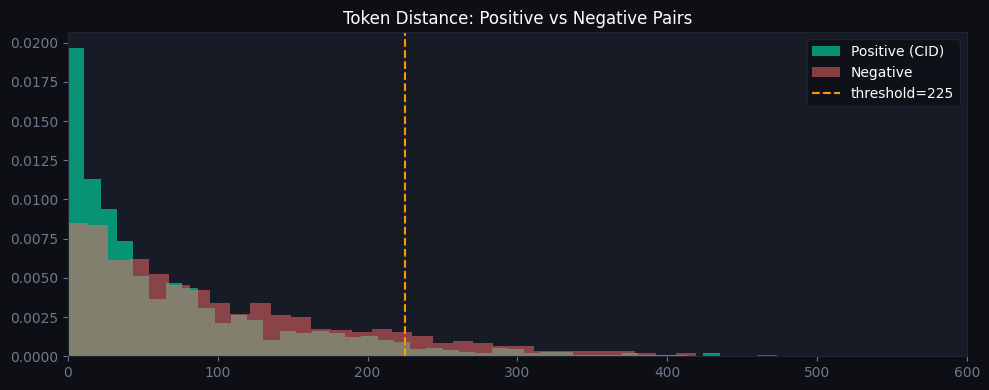

In [12]:
def token_dist(text, chem, disease, tok):
    lo = min(chem['end'],    disease['end'])
    hi = max(chem['start'], disease['start'])
    between = text[lo:hi] if lo < hi else ''
    return len(tok.encode(between, add_special_tokens=False))

pos_dists, neg_dists = [], []
for doc in train_docs:
    text      = doc['full_text']
    chem_map  = {e['mesh_id']: e for e in doc['entities'] if e['type']=='Chemical'}
    dis_map   = {e['mesh_id']: e for e in doc['entities'] if e['type']=='Disease'}
    pos_pairs = {(r['chem_id'], r['disease_id']) for r in doc['relations']}
    for cid, c in chem_map.items():
        for did, d in dis_map.items():
            try:
                dist = token_dist(text, c, d, tokenizer)
                if (cid, did) in pos_pairs: pos_dists.append(dist)
                else: neg_dists.append(dist)
            except: pass

pd_arr, nd_arr = np.array(pos_dists), np.array(neg_dists)
print(f'Positive pair dist — avg: {pd_arr.mean():.0f} | max: {pd_arr.max()} | p90: {np.percentile(pd_arr,90):.0f}')
print(f'Negative pair dist — avg: {nd_arr.mean():.0f} | max: {nd_arr.max()} | p90: {np.percentile(nd_arr,90):.0f}')

DISTANCE_THRESHOLD = int(np.percentile(pd_arr, 95))
filtered = (nd_arr > DISTANCE_THRESHOLD).sum()
print(f'\nDistance threshold (pos p95): {DISTANCE_THRESHOLD} tokens')
print(f'Negatives removed by filter : {filtered} ({100*filtered/len(nd_arr):.1f}%)')

fig, ax = plt.subplots(figsize=(10, 4), facecolor='#0d0f14')
ax.set_facecolor('#161b25')
ax.hist(pd_arr, bins=40, color='#00c896', alpha=0.7, label='Positive (CID)', density=True)
ax.hist(nd_arr, bins=40, color='#ff6b6b', alpha=0.5, label='Negative',       density=True)
ax.axvline(DISTANCE_THRESHOLD, color='#ff9800', linestyle='--', lw=1.5, label=f'threshold={DISTANCE_THRESHOLD}')
ax.set_xlim(0, 600)
ax.set_title('Token Distance: Positive vs Negative Pairs', color='white')
ax.tick_params(colors='#6b7a8d'); ax.spines[:].set_color('#1e2635')
ax.legend(facecolor='#0d0f14', edgecolor='#1e2635', labelcolor='white')
plt.tight_layout(); plt.show()

## PHASE 7 — Duplicate & Mention Complexity

In [13]:
from collections import Counter

multi_docs = []
for doc in train_docs:
    cc = Counter(e['mesh_id'] for e in doc['entities'] if e['type']=='Chemical' and e['mesh_id'])
    dc = Counter(e['mesh_id'] for e in doc['entities'] if e['type']=='Disease'  and e['mesh_id'])
    mc = max(cc.values(), default=0)
    md = max(dc.values(), default=0)
    if mc > 2 or md > 2:
        multi_docs.append({'pmid': doc['pmid'], 'max_chem': mc, 'max_dis': md})

print(f'Docs with repeated MeSH IDs (>2 mentions): {len(multi_docs)}')
for d in sorted(multi_docs, key=lambda x: -(x['max_chem']+x['max_dis']))[:5]:
    print(f"  PMID {d['pmid']}: max_chem_mentions={d['max_chem']}, max_dis_mentions={d['max_dis']}")
print('\nStrategy: use FIRST mention offset for marker insertion. BIO tagging covers all mentions for NER.')

Docs with repeated MeSH IDs (>2 mentions): 473
  PMID 11773892: max_chem_mentions=6, max_dis_mentions=29
  PMID 10669626: max_chem_mentions=16, max_dis_mentions=18
  PMID 10704919: max_chem_mentions=20, max_dis_mentions=11
  PMID 19356053: max_chem_mentions=13, max_dis_mentions=14
  PMID 14659530: max_chem_mentions=10, max_dis_mentions=14

Strategy: use FIRST mention offset for marker insertion. BIO tagging covers all mentions for NER.


## PHASE 8 — Negative Sampling Optimization

In [14]:
NEG_RATIO = 3

easy, hard = 0, 0
for doc in train_docs[:100]:
    text      = doc['full_text']
    chem_ents = [e for e in doc['entities'] if e['type']=='Chemical']
    dis_ents  = [e for e in doc['entities'] if e['type']=='Disease']
    pos_pairs = {(r['chem_id'], r['disease_id']) for r in doc['relations']}
    for c in chem_ents:
        for d in dis_ents:
            if (c['mesh_id'], d['mesh_id']) not in pos_pairs:
                try:
                    dist = token_dist(text, c, d, tokenizer)
                    if dist > DISTANCE_THRESHOLD: easy += 1
                    else: hard += 1
                except: pass

print(f'Easy negatives (dist > {DISTANCE_THRESHOLD}) in first 100 docs: {easy}')
print(f'Hard negatives (close, no CID)            in first 100 docs: {hard}')
print(f'\nFinal strategy:')
print(f'  1. Drop easy negatives beyond distance threshold {DISTANCE_THRESHOLD}')
print(f'  2. Downsample remaining negatives to 1:{NEG_RATIO} pos:neg')
print(f'  3. Apply pos_weight in BCEWithLogitsLoss for residual imbalance')

Easy negatives (dist > 225) in first 100 docs: 825
Hard negatives (close, no CID)            in first 100 docs: 4584

Final strategy:
  1. Drop easy negatives beyond distance threshold 225
  2. Downsample remaining negatives to 1:3 pos:neg
  3. Apply pos_weight in BCEWithLogitsLoss for residual imbalance


## PHASE 9 — Entity Marker Readiness

In [15]:
def insert_markers(text, chem, disease):
    spans = sorted([
        (chem['start'],    chem['end'],    '[CHEM]', '[/CHEM]'),
        (disease['start'], disease['end'], '[DIS]',  '[/DIS]')
    ], key=lambda x: x[0])

    result = text
    offset = 0
    for (s, e, open_t, close_t) in spans:
        s2, e2 = s + offset, e + offset
        before = result[:s2]
        entity_text = result[s2:e2]
        after  = result[e2:]
        inserted = f"{open_t}{entity_text}{close_t}"
        result = before + inserted + after
        offset += len(open_t) + len(close_t)  # ← remove the +2
    return result

broken = 0
for doc in train_docs[:50]:
    text = doc['full_text']
    for c in [e for e in doc['entities'] if e['type']=='Chemical']:
        for d in [e for e in doc['entities'] if e['type']=='Disease']:
            try:
                m = insert_markers(text, c, d)
                if '[CHEM]' not in m or '[DIS]' not in m: broken += 1
            except: broken += 1

print(f'Marker insertion test (50 docs) — broken spans: {broken}')
doc  = train_docs[0]
chem = next((e for e in doc['entities'] if e['type']=='Chemical'), None)
dis  = next((e for e in doc['entities'] if e['type']=='Disease'),  None)
if chem and dis:
    print('\nSample marked text:')
    print(insert_markers(doc['full_text'], chem, dis)[:400], '...')

Marker insertion test (50 docs) — broken spans: 0

Sample marked text:
[CHEM]Naloxone[/CHEM] reverses the antihypertensive effect of clonidine. In unanesthetized, spontaneously [DIS]hypertensive[/DIS] rats the decrease in blood pressure and heart rate produced by intravenous clonidine, 5 to 20 micrograms/kg, was inhibited or reversed by nalozone, 0.2 to 2 mg/kg. The hypotensive effect of 100 mg/kg alpha-methyldopa was also partially reversed by naloxone. Naloxone alo ...


## PHASE 10 — Final Decisions & Optimized Sample Generation

In [16]:
import random
random.seed(42)

MAX_TOKEN_LEN = 512

print('=== FINAL MODELING DECISIONS ===')
print(f'  max_token_length    : {MAX_TOKEN_LEN}')
print( '  input_level         : abstract (cross-sentence CIDs are common)')
print(f'  neg_sampling        : 1:{NEG_RATIO} after distance filtering')
print(f'  distance_threshold  : {DISTANCE_THRESHOLD} tokens')
print( '  class_balancing     : pos_weight in BCEWithLogitsLoss')
print( '  entity_markers      : [CHEM] [/CHEM] [DIS] [/DIS]')
print( '  mention_strategy    : first mention offset per MeSH ID')

def build_re_samples(docs, neg_ratio=NEG_RATIO, dist_thresh=DISTANCE_THRESHOLD):
    positives, negatives = [], []
    for doc in docs:
        text      = doc['full_text']
        pos_pairs = {(r['chem_id'], r['disease_id']) for r in doc['relations']}
        first_chem = {}
        for e in doc['entities']:
            if e['type'] == 'Chemical' and e['mesh_id'] not in first_chem:
                first_chem[e['mesh_id']] = e
        first_dis = {}
        for e in doc['entities']:
            if e['type'] == 'Disease' and e['mesh_id'] not in first_dis:
                first_dis[e['mesh_id']] = e

        for cid, c in first_chem.items():
            for did, d in first_dis.items():
                try:
                    dist   = token_dist(text, c, d, tokenizer)
                    marked = insert_markers(text, c, d)
                    sample = {'text': marked, 'label': 0, 'pmid': doc['pmid'],
                              'chemical': c['text'], 'disease': d['text']}
                    if (cid, did) in pos_pairs:
                        sample['label'] = 1
                        positives.append(sample)
                    elif dist <= dist_thresh:
                        negatives.append(sample)
                except: pass

    random.shuffle(negatives)
    negatives = negatives[:len(positives) * neg_ratio]
    all_s = positives + negatives
    random.shuffle(all_s)
    return all_s, len(positives), len(negatives)

train_re, tr_p, tr_n = build_re_samples(train_docs)
dev_re,   dv_p, dv_n = build_re_samples(dev_docs)
test_re,  ts_p, ts_n = build_re_samples(test_docs)

POS_WEIGHT = tr_n / max(tr_p, 1)

print(f'\nRE samples — Train: {len(train_re)} ({tr_p}+ / {tr_n}-)')
print(f'             Dev  : {len(dev_re)} ({dv_p}+ / {dv_n}-)')
print(f'             Test : {len(test_re)} ({ts_p}+ / {ts_n}-)')
print(f'\npos_weight for loss: {POS_WEIGHT:.2f}')
print('\nEDA COMPLETE. Dataset is clean, validated, and pipeline-ready.')

=== FINAL MODELING DECISIONS ===
  max_token_length    : 512
  input_level         : abstract (cross-sentence CIDs are common)
  neg_sampling        : 1:3 after distance filtering
  distance_threshold  : 225 tokens
  class_balancing     : pos_weight in BCEWithLogitsLoss
  entity_markers      : [CHEM] [/CHEM] [DIS] [/DIS]
  mention_strategy    : first mention offset per MeSH ID

RE samples — Train: 3944 (986+ / 2958-)
             Dev  : 3844 (961+ / 2883-)
             Test : 4168 (1042+ / 3126-)

pos_weight for loss: 3.00

EDA COMPLETE. Dataset is clean, validated, and pipeline-ready.


---
## NER Training — PubMedBERT Token Classification

In [17]:
import torch
from torch.utils.data import Dataset
from transformers import (AutoModelForTokenClassification, TrainingArguments,
                          Trainer, DataCollatorForTokenClassification)
from seqeval.metrics import f1_score, precision_score, recall_score

LABEL2ID = {'O':0,'B-Chemical':1,'I-Chemical':2,'B-Disease':3,'I-Disease':4}
ID2LABEL = {v:k for k,v in LABEL2ID.items()}

def char_to_bio(text, entities):
    labels = ['O'] * len(text)
    for ent in entities:
        if ent['type'] not in ('Chemical','Disease'): continue
        s, e = ent['start'], ent['end']
        if s >= len(labels): continue
        labels[s] = f"B-{ent['type']}"
        for i in range(s+1, min(e, len(labels))): labels[i] = f"I-{ent['type']}"
    return labels

def tokenize_and_align(doc, tok):
    text = doc['full_text']
    char_labels = char_to_bio(text, doc['entities'])
    enc = tok(text, truncation=True, max_length=MAX_TOKEN_LEN, return_offsets_mapping=True)
    token_labels = []
    for s, e in enc['offset_mapping']:
        if s == e: token_labels.append(-100)
        else: token_labels.append(LABEL2ID.get(char_labels[s] if s < len(char_labels) else 'O', 0))
    enc.pop('offset_mapping')
    enc['labels'] = token_labels
    return enc

class NERDataset(Dataset):
    def __init__(self, docs, tok):
        self.data = [tokenize_and_align(d, tok) for d in docs]
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return {k: torch.tensor(v) for k,v in self.data[i].items()}

train_ner_ds = NERDataset(train_docs, tokenizer)
dev_ner_ds   = NERDataset(dev_docs,   tokenizer)
test_ner_ds  = NERDataset(test_docs,  tokenizer)
print(f'NER datasets — Train:{len(train_ner_ds)} Dev:{len(dev_ner_ds)} Test:{len(test_ner_ds)}')

NER datasets — Train:500 Dev:500 Test:500


In [18]:
ner_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABEL2ID), id2label=ID2LABEL, label2id=LABEL2ID)
collator = DataCollatorForTokenClassification(tokenizer)

def compute_ner_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    ts, ps = [], []
    for p_row, l_row in zip(preds, labels):
        t, p = [], []
        for p_, l_ in zip(p_row, l_row):
            if l_ == -100: continue
            t.append(ID2LABEL[l_]); p.append(ID2LABEL[p_])
        ts.append(t); ps.append(p)
    return {'f1': f1_score(ts, ps), 'precision': precision_score(ts, ps), 'recall': recall_score(ts, ps)}

ner_args = TrainingArguments(
    output_dir='./ner_checkpoints', num_train_epochs=5,
    per_device_train_batch_size=8, per_device_eval_batch_size=8,
    learning_rate=2e-5, warmup_ratio=0.1, weight_decay=0.01,
    eval_strategy='epoch', save_strategy='epoch',
    load_best_model_at_end=True, metric_for_best_model='f1',
    fp16=True, logging_steps=50
)

ner_trainer = Trainer(
    model=ner_model, args=ner_args,
    train_dataset=train_ner_ds, eval_dataset=dev_ner_ds,
    processing_class=tokenizer, data_collator=collator,
    compute_metrics=compute_ner_metrics
)
ner_trainer.train()


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.818171,0.172438,0.779851,0.770349,0.789590
2,0.156189,0.094312,0.859170,0.830753,0.889600
3,0.089273,0.085166,0.872796,0.850667,0.896107
4,0.052585,0.083458,0.880470,0.858439,0.903663
5,0.044361,0.084513,0.884045,0.864493,0.904502


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=315, training_loss=0.19645626034055438, metrics={'train_runtime': 152.1994, 'train_samples_per_second': 16.426, 'train_steps_per_second': 2.07, 'total_flos': 552073778945520.0, 'train_loss': 0.19645626034055438, 'epoch': 5.0})

In [19]:
ner_test = ner_trainer.evaluate(test_ner_ds)
print('NER Test:')
for k, v in ner_test.items():
    if isinstance(v, float): print(f'  {k}: {v:.4f}')
ner_trainer.save_model('./ner_model')
tokenizer.save_pretrained('./ner_model')
print('Saved ./ner_model')

NER Test:
  eval_loss: 0.0931
  eval_f1: 0.8644
  eval_precision: 0.8398
  eval_recall: 0.8904
  eval_runtime: 4.3003
  eval_samples_per_second: 116.2700
  eval_steps_per_second: 14.6500
  epoch: 5.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved ./ner_model


## RE Training — PubMedBERT Sequence Classification

In [20]:
from transformers import AutoTokenizer as AT, AutoModelForSequenceClassification
from sklearn.metrics import f1_score as sk_f1, precision_score as sk_p, recall_score as sk_r
NER_MODEL_NAME = "dmis-lab/biobert-base-cased-v1.1"
# Special tokens shared by BOTH tokenizers
SPECIAL_TOKENS = ['[CHEM]','[/CHEM]','[DIS]','[/DIS]']

# RE tokenizer
re_tokenizer = AT.from_pretrained(MODEL_NAME)
re_tokenizer.add_special_tokens({'additional_special_tokens': SPECIAL_TOKENS})

# NER tokenizer (IMPORTANT FIX)
ner_tokenizer = AT.from_pretrained(NER_MODEL_NAME)
ner_tokenizer.add_special_tokens({'additional_special_tokens': SPECIAL_TOKENS})

class REDataset(Dataset):
    def __init__(self, samples, tok):
        self.samples = samples
        self.tok = tok

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        s = self.samples[i]
        enc = self.tok(
            s['text'][:1000],
            truncation=True,
            max_length=MAX_TOKEN_LEN,
            padding='max_length'
        )

        return {
            'input_ids': torch.tensor(enc['input_ids']),
            'attention_mask': torch.tensor(enc['attention_mask']),
            'labels': torch.tensor(s['label'])
        }

train_re_ds = REDataset(train_re, re_tokenizer)
dev_re_ds   = REDataset(dev_re, re_tokenizer)
test_re_ds  = REDataset(test_re, re_tokenizer)

print(f'RE datasets — Train:{len(train_re_ds)} Dev:{len(dev_re_ds)} Test:{len(test_re_ds)}')

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

RE datasets — Train:3944 Dev:3844 Test:4168


In [21]:
from transformers import AutoModel
import torch.nn as nn
import torch

class REEntityModel(nn.Module):
    def __init__(self, model_name, num_labels, tokenizer):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.bert.resize_token_embeddings(len(tokenizer))

        hidden = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.2)

        # CHEM + DIS embeddings concatenated
        self.classifier = nn.Linear(hidden * 2, num_labels)

        # Token IDs
        self.chem_id = tokenizer.convert_tokens_to_ids('[CHEM]')
        self.dis_id  = tokenizer.convert_tokens_to_ids('[DIS]')

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        last_hidden = outputs.last_hidden_state  # [B, L, H]
        batch_size = input_ids.size(0)

        chem_vecs = []
        dis_vecs = []

        for i in range(batch_size):
            ids = input_ids[i]

            chem_pos = (ids == self.chem_id).nonzero(as_tuple=True)[0]
            dis_pos  = (ids == self.dis_id).nonzero(as_tuple=True)[0]

            # fallback if marker missing
            chem_idx = chem_pos[0] if len(chem_pos) > 0 else 0
            dis_idx  = dis_pos[0] if len(dis_pos) > 0 else 0

            chem_vecs.append(last_hidden[i, chem_idx])
            dis_vecs.append(last_hidden[i, dis_idx])

        chem_vecs = torch.stack(chem_vecs)
        dis_vecs = torch.stack(dis_vecs)

        entity_rep = torch.cat([chem_vecs, dis_vecs], dim=1)

        logits = self.classifier(self.dropout(entity_rep))

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return {
            "loss": loss,
            "logits": logits
        }

In [22]:
import os
import torch
import numpy as np
from sklearn.metrics import f1_score as sk_f1, precision_score as sk_p, recall_score as sk_r

re_model = REEntityModel(MODEL_NAME, num_labels=2, tokenizer=re_tokenizer)
re_model.bert.resize_token_embeddings(len(re_tokenizer))
re_model.bert.embeddings.word_embeddings.weight.data = \
    re_model.bert.embeddings.word_embeddings.weight.data.contiguous()

def compute_re_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'f1':        sk_f1(labels, preds, average='binary'),
        'precision': sk_p(labels, preds, average='binary', zero_division=0),
        'recall':    sk_r(labels, preds, average='binary', zero_division=0)
    }

class RETrainer(Trainer):
    def save_model(self, output_dir=None, _internal_call=False):
        output_dir = output_dir or self.args.output_dir
        os.makedirs(output_dir, exist_ok=True)
        state_dict = {k: v.contiguous() for k, v in self.model.state_dict().items()}
        torch.save(state_dict, os.path.join(output_dir, 'pytorch_model.bin'))

    def _load_best_model(self):
        best_ckpt = os.path.join(self.state.best_model_checkpoint, 'pytorch_model.bin')
        if os.path.exists(best_ckpt):
            state_dict = torch.load(best_ckpt, map_location='cpu')
            self.model.load_state_dict(state_dict)

re_args = TrainingArguments(
    output_dir='./re_checkpoints', num_train_epochs=4,
    per_device_train_batch_size=16, per_device_eval_batch_size=16,
    learning_rate=2e-5, warmup_ratio=0.1, weight_decay=0.01,
    eval_strategy='epoch', save_strategy='epoch',
    load_best_model_at_end=True, metric_for_best_model='f1',
    fp16=True,
)

re_trainer = RETrainer(
    model=re_model, args=re_args,
    train_dataset=train_re_ds, eval_dataset=dev_re_ds,
    processing_class=re_tokenizer, compute_metrics=compute_re_metrics
)
re_trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mea

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,0.414758,0.667244,0.571111,0.802289
2,No log,0.397159,0.667363,0.669811,0.664932
3,0.403367,0.455878,0.675578,0.667683,0.683663
4,0.403367,0.487874,0.677635,0.669715,0.685744


TrainOutput(global_step=988, training_loss=0.28292120033912815, metrics={'train_runtime': 616.79, 'train_samples_per_second': 25.578, 'train_steps_per_second': 1.602, 'total_flos': 0.0, 'train_loss': 0.28292120033912815, 'epoch': 4.0})

In [23]:
preds_output = re_trainer.predict(dev_re_ds)

all_logits = preds_output.predictions
all_labels = preds_output.label_ids

In [24]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import torch

probs = torch.softmax(torch.tensor(all_logits), dim=-1)[:, 1].numpy()

best_thresh = 0.5
best_f1 = 0

print("Threshold Sweep Results:\n")

for t in np.arange(0.30, 0.81, 0.02):
    preds = (probs >= t).astype(int)

    f1 = f1_score(all_labels, preds, zero_division=0)
    precision = precision_score(all_labels, preds, zero_division=0)
    recall = recall_score(all_labels, preds, zero_division=0)

    print(
        f"Threshold={t:.2f} | "
        f"F1={f1:.4f} | "
        f"P={precision:.4f} | "
        f"R={recall:.4f}"
    )

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"\nBest threshold: {best_thresh:.2f} → F1: {best_f1:.4f}")

Threshold Sweep Results:

Threshold=0.30 | F1=0.6813 | P=0.6306 | R=0.7409
Threshold=0.32 | F1=0.6814 | P=0.6330 | R=0.7378
Threshold=0.34 | F1=0.6812 | P=0.6365 | R=0.7326
Threshold=0.36 | F1=0.6800 | P=0.6400 | R=0.7253
Threshold=0.38 | F1=0.6821 | P=0.6471 | R=0.7211
Threshold=0.40 | F1=0.6795 | P=0.6484 | R=0.7138
Threshold=0.42 | F1=0.6770 | P=0.6498 | R=0.7066
Threshold=0.44 | F1=0.6754 | P=0.6531 | R=0.6993
Threshold=0.46 | F1=0.6761 | P=0.6562 | R=0.6972
Threshold=0.48 | F1=0.6796 | P=0.6657 | R=0.6941
Threshold=0.50 | F1=0.6776 | P=0.6697 | R=0.6857
Threshold=0.52 | F1=0.6743 | P=0.6732 | R=0.6753
Threshold=0.54 | F1=0.6747 | P=0.6771 | R=0.6722
Threshold=0.56 | F1=0.6733 | P=0.6820 | R=0.6649
Threshold=0.58 | F1=0.6723 | P=0.6889 | R=0.6566
Threshold=0.60 | F1=0.6713 | P=0.6901 | R=0.6535
Threshold=0.62 | F1=0.6703 | P=0.6950 | R=0.6472
Threshold=0.64 | F1=0.6678 | P=0.6993 | R=0.6389
Threshold=0.66 | F1=0.6648 | P=0.7030 | R=0.6306
Threshold=0.68 | F1=0.6582 | P=0.7038 | R=0

In [25]:

import os
import torch

os.makedirs("./re_model", exist_ok=True)

torch.save(
    re_model.state_dict(),
    "./re_model/re_model.pt"
)

re_tokenizer.save_pretrained("./re_model")

print("Saved:")
print("./re_model/re_model.pt")
print("./re_model/tokenizer files")

✅ Saved:
./re_model/re_model.pt
./re_model/tokenizer files


In [27]:

import os
import shutil
import torch
from google.colab import files

os.makedirs("./ner_model", exist_ok=True)

ner_model.save_pretrained("./ner_model")
tokenizer.save_pretrained("./ner_model")


os.makedirs("./re_model", exist_ok=True)

torch.save(
    re_model.state_dict(),
    "./re_model/re_model.pt"
)

re_tokenizer.save_pretrained("./re_model")


with open("./re_model/model_info.txt", "w") as f:
    f.write("Custom REEntityModel\n")
    f.write(f"Base model: {MODEL_NAME}\n")
    f.write("Weights file: re_model.pt\n")
    f.write("num_labels: 2\n")


shutil.make_archive("ner_model", "zip", "./ner_model")
shutil.make_archive("re_model", "zip", "./re_model")


files.download("ner_model.zip")
files.download("re_model.zip")


print("DONE")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DONE
